<div style="font-family: Arial, sans-serif; background-color: #f8f9fa; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">
  <div style="display: flex; justify-content: space-between; align-items: center;">
    <img src="https://sigmoidal.ai/wp-content/uploads/2024/09/Academia-Sigmoidal-Light.png" alt="Academia Sigmoidal Logo" width="250" height="auto">
    <div style="text-align: right;">
<h1 style="color: #007bff; margin: 0; font-size: 24px;">Bootcamp de Visão Computacional Aplicada a Drones</h1>
    </div>
</div>
<hr style="border: none; height: 1px; background-color: #007bff; margin: 20px 0;">
<h3 style="color: #343a40; margin: 0; font-size: 20px;"><strong>Projeto 2 · Detecção com pesos treinados</strong></h3>
<p style="color: #6c757d; margin: 5px 0 0; font-size: 14px;"><strong>Instrutor:</strong> Carlos Melo, MSc.</p>
</div>

# Das duas imagens às detecções

O QFDet foi treinado pelos autores no **RGBTDronePerson**. Este notebook carrega os pesos publicados,
fornece um par RGB e térmico da validação e apresenta as caixas previstas.
**Inferência** é usar o modelo para produzir previsões, mantendo seus parâmetros fixos.

A atividade acompanha um único par do começo ao fim e propõe repetir o percurso com uma cena noturna.
As anotações são consultadas somente após a previsão, para comparação visual.

**Para executar:** prepare o ambiente descrito no [README](README.md) e selecione o kernel **Projeto 2 - QFDet CPU**.
O código oficial deve estar em `codigo/qfdet`. Na pasta `projeto-2`, execute
`.venv-qfdet-cpu/bin/python suporte/preparar_dados.py --rgbtdroneperson` para obter os dados usados na atividade.
O checkpoint será baixado e verificado por uma célula deste notebook, caso ainda esteja ausente.
O ambiente usa CPU e é diferente do ambiente dos Notebooks 00 e 01.

## Localizar os arquivos

`Path` representa um caminho. O trecho abaixo funciona ao abrir o notebook na pasta do Projeto 2
ou na raiz do repositório. `sys.path.insert` informa ao Python onde está a implementação oficial do QFDet.

In [1]:
from pathlib import Path
import sys

PROJETO = Path.cwd()
if not (PROJETO / "suporte").is_dir():
    PROJETO = PROJETO / "projeto-2"
FONTE = PROJETO / "codigo/qfdet"
DADOS = PROJETO / "dados"
PESO = PROJETO / "modelos/epoch_11_qfdet_rgbtdroneperson.pth"
sys.path.insert(0, str(PROJETO / "suporte"))
sys.path.insert(0, str(FONTE))

## Ferramentas para inferência

**PyTorch** executa a rede. **MMDetection** organiza os componentes do detector e o processamento das imagens;
os autores acrescentaram o QFDet a essa biblioteca. A implementação oficial permite concentrar a atividade
nas entradas e nas previsões.

`Config` lê a configuração do modelo; `build_detector` monta sua estrutura; `Compose` encadeia as operações
de preparação. NumPy, Pillow e Matplotlib continuam responsáveis pela inspeção e pelas figuras.

In [2]:
%matplotlib inline
import json
from time import perf_counter
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.patches import Rectangle
from mmcv import Config
from mmdet.models import build_detector
from mmdet.datasets.pipelines import Compose
plt.rcParams.update({"font.family": "sans-serif", "font.size": 11, "figure.dpi": 120})

<projeto-2>/.venv-qfdet-cpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Duas entradas, uma previsão conjunta

Cada imagem passa por uma **ResNet-50**, que extrai padrões locais, como contornos e outras características
aprendidas. A **FPN** organiza essas características em mapas de várias resoluções. Esses mapas são
descrições da cena que ainda guardam a localização dos padrões.

A **PreHead** estima a qualidade das características de cada modalidade. O **QCE** usa essa estimativa
para reforçá-las e combiná-las. A cabeça final transforma os mapas combinados em caixas, classes e pontuações.

Uma [nota técnica](NOTAS-TECNICAS.md) registra diferenças entre as equações do artigo e o código oficial
fixado. A atividade usa essa implementação sem alterar suas fórmulas ou seus pesos.

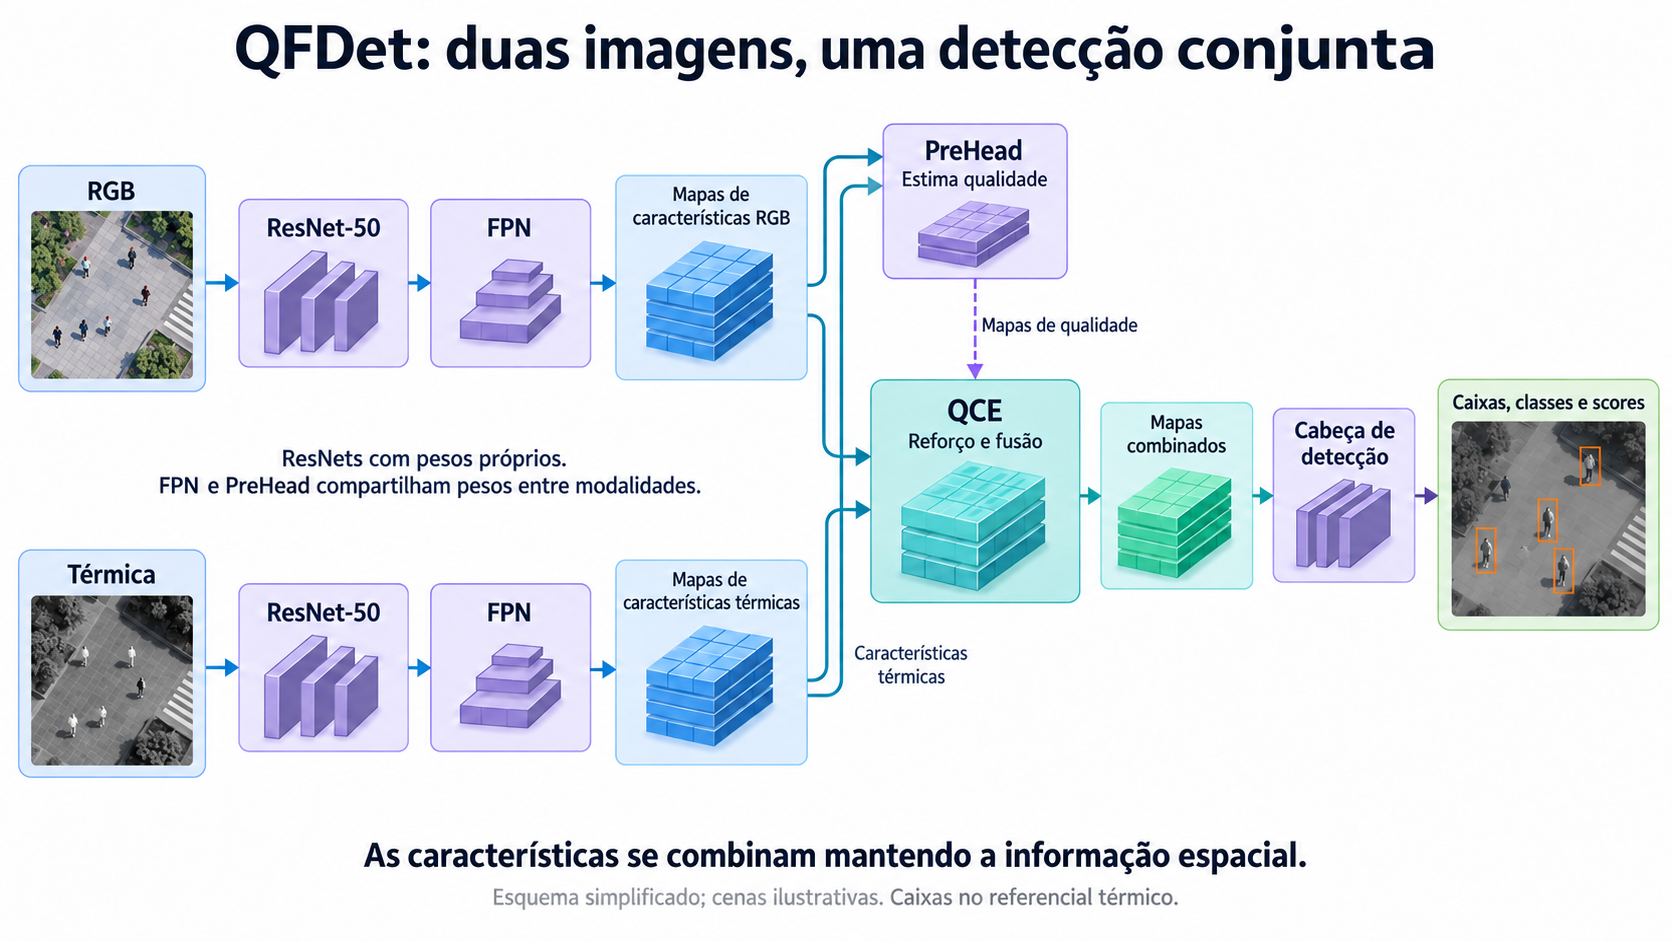

Fluxo simplificado da inferência. Cada modalidade fornece características à PreHead e ao QCE. A PreHead estima sua qualidade; o QCE usa essa informação para reforçá-las e combiná-las. As caixas finais usam o referencial térmico. As cenas são ilustrativas.

As duas ResNets têm parâmetros próprios. Na implementação usada aqui, a FPN e a PreHead compartilham
seus parâmetros entre as modalidades. **As imagens não viram um vetor único achatado:** a fusão reúne
os canais das características e mantém a grade espacial em cada resolução.

Os pares mostram a mesma cena, mas não estão perfeitamente alinhados. O QFDet processa também a vizinhança
das características RGB para reduzir o impacto desses deslocamentos; ele não devolve uma fotografia RGB corrigida.
**As caixas finais usam as coordenadas da imagem térmica.**

## Estrutura e aprendizado são duas peças

A **arquitetura** define as camadas e suas conexões. A **configuração** especifica quais componentes montar.
Os **pesos** são os valores ajustados no treinamento, e o **checkpoint** é o arquivo que guarda esses valores.
Dentro dele, `state_dict` associa nomes de parâmetros aos respectivos tensores, que são arrays do PyTorch.

A atividade usa o [checkpoint oficial dos autores](https://drive.google.com/file/d/1TuVXy_h0PxTK8qLY1MgqJTNiAumV8p0V/view),
`epoch_11_qfdet_rgbtdroneperson.pth`. Ele contém o aprendizado do detector para este dataset, e não apenas
os pesos de uma ResNet genérica. Os nomes das classes também estão nos metadados do checkpoint.

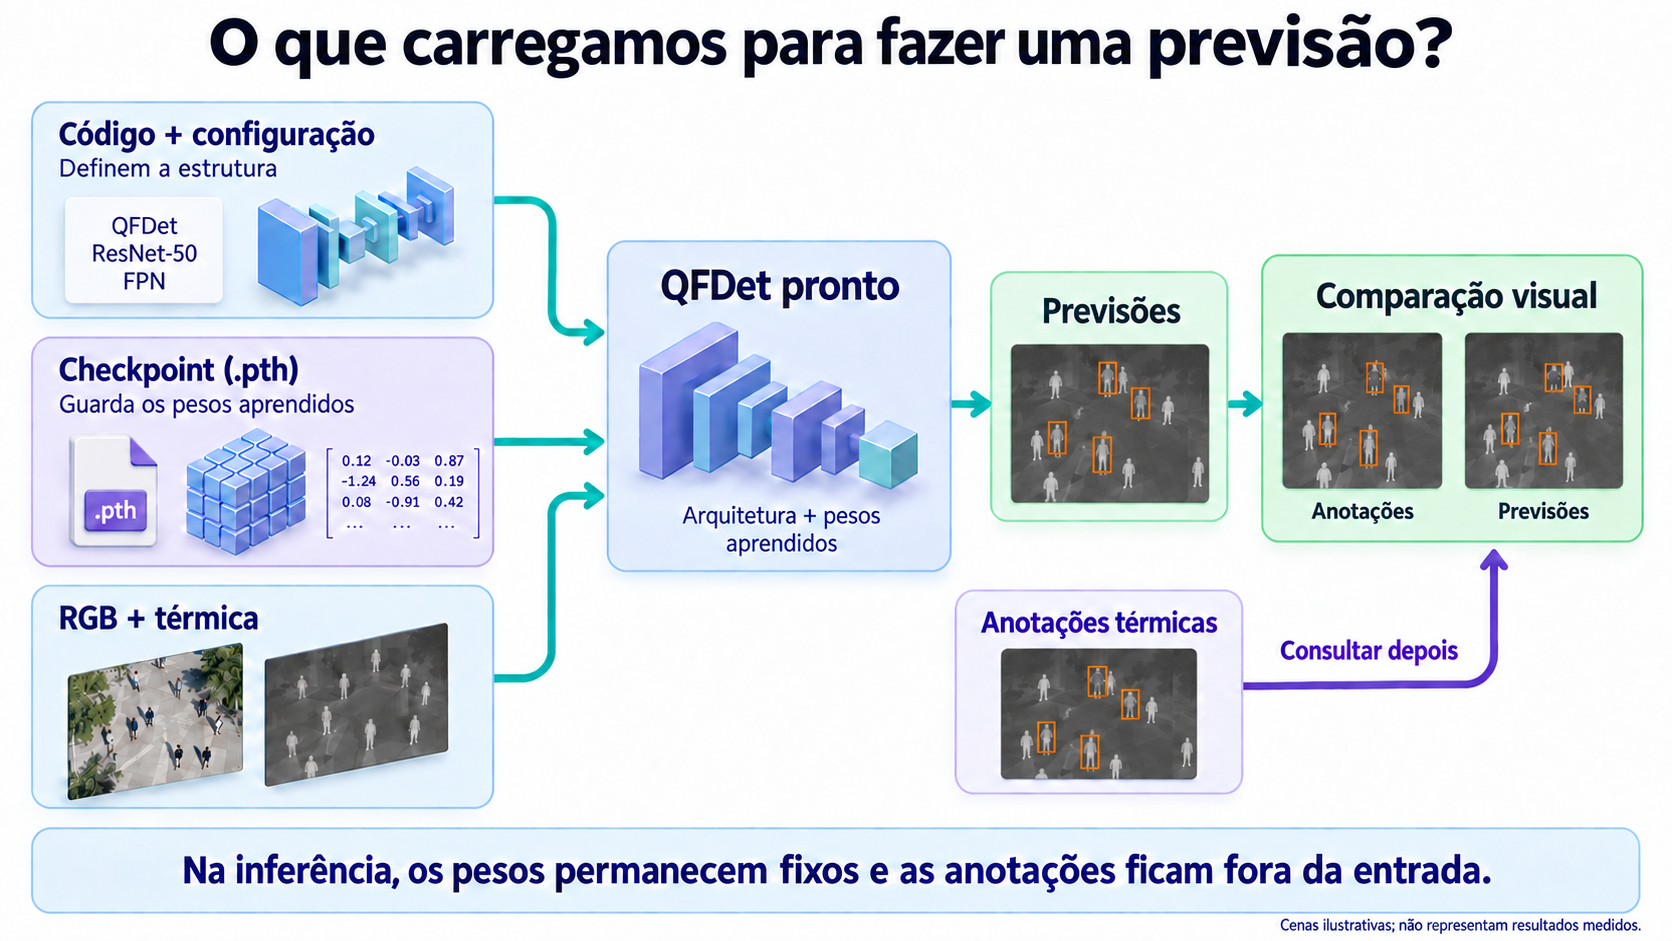

A configuração define a estrutura e o checkpoint fornece os parâmetros aprendidos. As imagens geram previsões; as anotações servem apenas à comparação posterior. As cenas e os valores de pesos do desenho são ilustrativos; os resultados reais aparecem nas células abaixo.

## Obter o checkpoint publicado

`preparar_pesos` baixa o arquivo oficial quando necessário e confere seu SHA-256 antes do carregamento.
O checkpoint tem aproximadamente 485 MB. A função reutiliza uma cópia local válida em `modelos/` e interrompe a execução se o download ou a verificação falhar.
O hash identifica o arquivo de referência utilizado nesta atividade; não é uma assinatura publicada pelos autores.

In [3]:
from preparar_dados import preparar_pesos

PESO = preparar_pesos(PROJETO, "rgbtdroneperson")
print("Checkpoint disponível:", PESO.name)

Checkpoint disponível: epoch_11_qfdet_rgbtdroneperson.pth


## Montar a estrutura na CPU

A primeira etapa monta a estrutura. `train_cfg = None` deixa de fornecer regras de treinamento.
`init_cfg = None` evita carregar uma inicialização adicional da ResNet, pois a rede receberá
o checkpoint completo. `.cpu()` escolhe o processador, e quatro threads limitam o paralelismo local.

Há um pequeno detalhe de compatibilidade: o checkpoint também guarda parâmetros de alternativas de fusão
que esta configuração não utiliza. A lista abaixo identifica somente essas alternativas; a próxima célula
desconsidera seus seis tensores, preservando todos os parâmetros da arquitetura ativa.

In [4]:
config = Config.fromfile(str(FONTE / "qfdet_configs/qfdet_r50_fpn_1x_rgbtdroneperson.py"))
config.model.train_cfg = None
config.model.backbone.init_cfg = None
torch.set_num_threads(4)
modelo = build_detector(config.model).cpu()
ramos_inativos = (
    "fuse.fusion_cat2.conv1x1",
    "fuse.fusion_gated.t_conv1x1",
    "fuse.fusion_gated.v_conv1x1",
)

<projeto-2>/codigo/qfdet/mmdet/models/dense_heads/anchor_head.py:116: UserWarning: DeprecationWarning: `num_anchors` is deprecated, for consistency or also use `num_base_priors` instead
  warnings.warn('DeprecationWarning: `num_anchors` is deprecated, '


## Carregar o que o modelo aprendeu

`ler_checkpoint_restrito` lê o arquivo na CPU usando o mesmo leitor restrito do Notebook 03.
O SHA-256 já foi conferido por `preparar_pesos`; o leitor permite somente os tipos necessários aos tensores. Em cada ramo inativo existem um `weight` e um `bias`;
o conjunto `extras` contém seus nomes. O `assert` confirma a exclusão de apenas os extras conhecidos.
A filtragem cria um novo dicionário na memória e não altera o arquivo original.

`load_state_dict(..., strict=True)` exige correspondência de todos os parâmetros restantes com a rede.
Depois, `.eval()` seleciona o comportamento de inferência de camadas como BatchNorm; **não calcula métricas**.
A atribuição do retorno a `_` evita imprimir a estrutura inteira do modelo.

In [5]:
from qfdet_video import ler_checkpoint_restrito
checkpoint = ler_checkpoint_restrito(PESO)
pesos = checkpoint["state_dict"]
extras = {f"{ramo}.{p}" for ramo in ramos_inativos for p in ("weight", "bias")}
assert config.model.base_fusion == "cat" and set(pesos) - set(modelo.state_dict()) == extras
pesos = {nome: valor for nome, valor in pesos.items() if nome not in extras}
_ = modelo.load_state_dict(pesos, strict=True)
_ = modelo.eval()
classes = tuple(checkpoint["meta"]["CLASSES"])
print("Pesos carregados. Classes:", classes)
del checkpoint, pesos

Pesos carregados. Classes: ('person', 'rider', 'crowd')


O detector trabalha com `person` (pessoa), `rider` (pessoa em bicicleta ou scooter) e `crowd` (grupo de pessoas).
`uncertain`, vista na exploração do dataset, não é uma classe prevista pelo modelo.

## Escolher um par da validação

A primeira amostra é a cena diurna `05350.jpg`. Os dois arquivos têm o mesmo nome, mas estão em pastas diferentes.
`np.array` converte a imagem aberta pelo Pillow em um array; essas versões originais serão usadas nas figuras.

O artigo (§5.1) informa que a época final foi escolhida pelo melhor resultado no conjunto de avaliação,
chamado *testing* pelos autores. Assim, estes pares não representam um teste final independente da seleção
do modelo. Isso não significa que suas anotações tenham sido usadas para atualizar os pesos.
A demonstração aqui é qualitativa; não estima a qualidade do detector em novos dados.

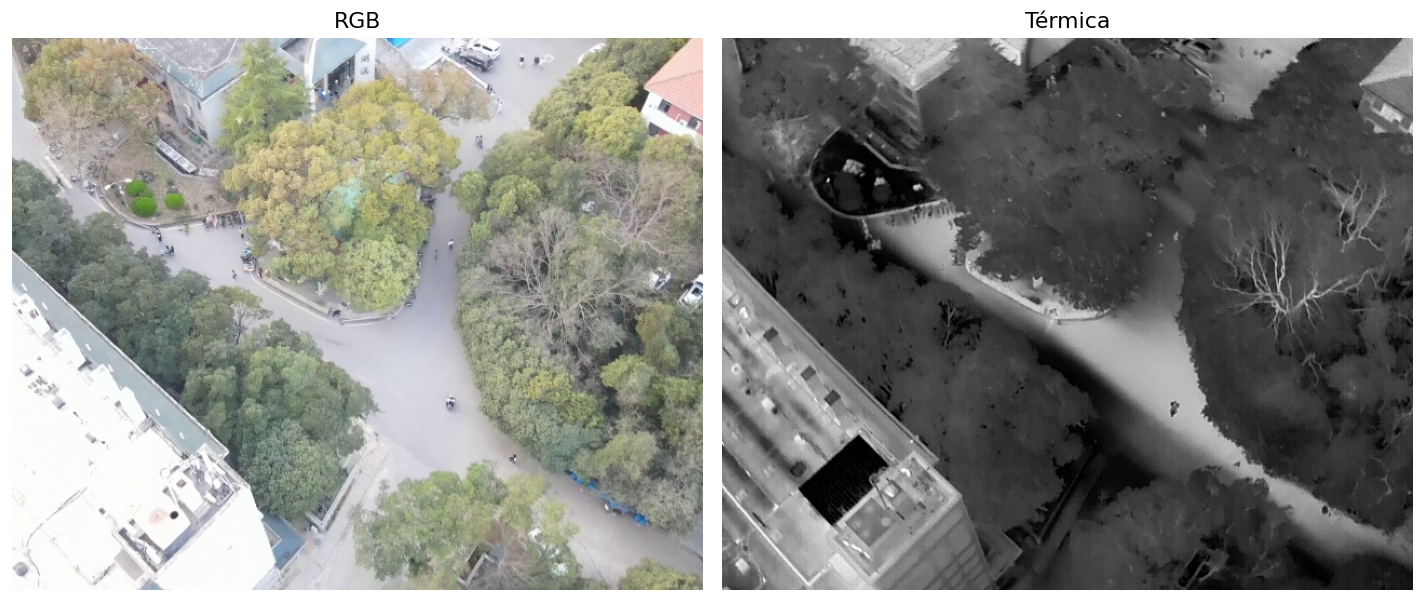

In [6]:
ARQUIVO = "05350.jpg"
rgb = np.array(Image.open(DADOS / "val/visible" / ARQUIVO).convert("RGB"))
termica = np.array(Image.open(DADOS / "val/thermal" / ARQUIVO).convert("RGB"))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, imagem, titulo in zip(axes, [rgb, termica], ["RGB", "Térmica"]):
    ax.imshow(imagem)
    ax.set_title(titulo)
    ax.axis("off")
plt.tight_layout()
plt.show()

A rede recebe as duas modalidades. O JPEG térmico tem três canais com a mesma intensidade,
como observado anteriormente; isso não significa três medições térmicas, nem valores em graus Celsius.

## Retomar a preparação do Notebook 01

A sequência oficial de **inferência** inclui: leitura do par, ajuste de tamanho, normalização por sensor,
organização dos canais e preparação dos tensores. Nesta configuração não há espelhamento aleatório.
Como as imagens já têm 640 × 512 pixels, o ajuste de tamanho e o preenchimento não mudam suas dimensões.

A normalização continua usando os valores de pixels entre 0 e 255, com médias e desvios próprios de cada sensor.
Não se divide novamente por 255. `Compose` reaproveita exatamente as operações declaradas na configuração.

O retorno contém pequenos recipientes do MMDetection: `.data` acessa seu conteúdo.
`unsqueeze(0)` acrescenta o eixo do **lote**, formando `(1, 3, 512, 640)`:
**uma imagem, três canais, 512 linhas e 640 colunas**, em cada modalidade.
`metadados` guarda tamanhos e escalas para interpretar as coordenadas; não contém anotações.

In [7]:
preparar = Compose(config.data.test.pipeline)
amostra = preparar(dict(img_info=dict(filename=ARQUIVO), img_prefix=str(DADOS / "val")))
par = [recipiente.data.unsqueeze(0) for recipiente in amostra["img"][0]]
metadados = amostra["img_metas"][0].data
print("RGB:", tuple(par[0].shape), par[0].dtype)
print("Térmica:", tuple(par[1].shape), par[1].dtype)

RGB: (1, 3, 512, 640) torch.float32
Térmica: (1, 3, 512, 640) torch.float32


## Fazer a previsão

`torch.inference_mode()` desativa o acompanhamento de gradientes, que seria necessário para aprender novos pesos.
É complementar a `.eval()`: esta etapa calcula uma saída com o modelo carregado.

Na chamada, `return_loss=False` solicita previsões e `rescale=True` expressa as caixas no tamanho original da imagem.
As listas externas em `img=[par]` e `img_metas=[[metadados]]` seguem a interface do MMDetection para escalas de teste;
a configuração usa uma única escala. O `[0]` final seleciona o resultado do único par do lote.

O tempo abaixo mede a chamada ao detector, incluindo seu processamento final de caixas.
Não inclui a leitura das imagens, a preparação nem o carregamento dos pesos.

In [8]:
inicio = perf_counter()
with torch.inference_mode():
    resultado = modelo(return_loss=False, rescale=True,
                       img=[par], img_metas=[[metadados]])[0]
segundos = perf_counter() - inicio
print(f"Inferência em CPU: {segundos:.2f} s")

Inferência em CPU: 3.05 s


## Ler caixas, classes e pontuações

`resultado` é uma lista com três arrays, na ordem de `classes`. Por isso, `resultado[0]` reúne as detecções de `person`.
**A classe vem do grupo ao qual a linha pertence**; não há uma sexta coluna de classe no retorno original.

Cada linha tem cinco valores: `[x1, y1, x2, y2, score]`. Os quatro primeiros são os cantos superior esquerdo
e inferior direito da caixa, em pixels da térmica. O `score` é uma pontuação de confiança: `0.80` não garante
que aquela previsão tenha 80% de chance de estar correta.

A célula mostra três linhas com duas casas decimais e seleciona as previsões com `score >= 0.30`.
`zip` percorre classes e arrays em conjunto; cada item de `previsoes` guarda um texto e uma caixa para desenhar.
A quantidade selecionada conta **previsões exibidas**, não acertos.

In [9]:
np.set_printoptions(precision=2, suppress=True)
print("Exemplos de person: [x1, y1, x2, y2, score]")
print(resultado[0][:3])
LIMIAR = 0.30
previsoes = []
for classe, caixas in zip(classes, resultado):
    for x1, y1, x2, y2, score in caixas:
        if score >= LIMIAR:
            previsoes.append((f"{classe} {score:.2f}", (x1, y1, x2, y2)))
print("Previsões selecionadas:", len(previsoes))

Exemplos de person: [x1, y1, x2, y2, score]
[[414.65 177.76 421.89 189.7    0.45]
 [402.05 187.91 409.25 200.6    0.36]
 [476.38   6.71 483.98  19.48   0.28]]
Previsões selecionadas: 4


## Desenhar as previsões na térmica

Esta pequena função faz somente a visualização. Para desenhar um `Rectangle`, os dois cantos são convertidos
em origem, largura e altura: `(x1, y1)`, `x2 - x1` e `y2 - y1`, retomando o Notebook 01.
`plt.text` coloca a classe e o score junto à caixa.

O RGB contribuiu para a previsão, mas as caixas abaixo estão no **referencial térmico**.
Colocá-las diretamente no RGB não criaria anotações RGB nem corrigiria o desalinhamento.

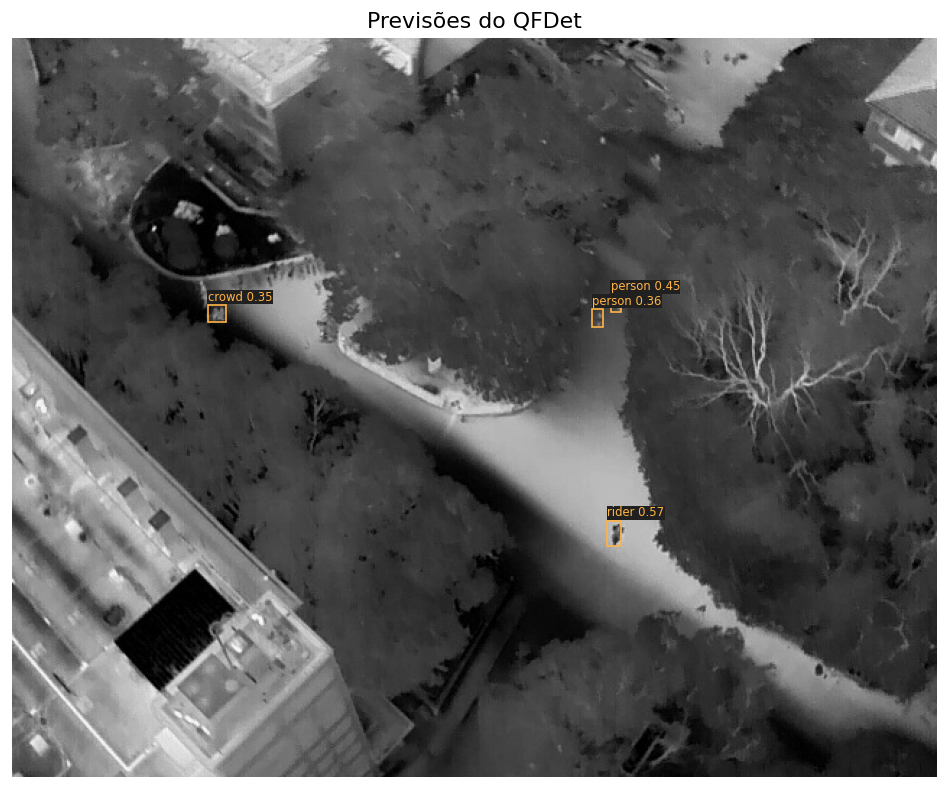

In [10]:
def mostrar_caixas(imagem, objetos, titulo, cor):
    plt.imshow(imagem, extent=(0, imagem.shape[1], imagem.shape[0], 0))
    for rotulo, (x1, y1, x2, y2) in objetos:
        plt.gca().add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color=cor))
        plt.text(x1, y1 - 3, rotulo, color=cor, fontsize=7,
                 bbox=dict(facecolor="#202020", edgecolor="none", pad=0.3))
    plt.title(titulo)
    plt.axis("off")

plt.figure(figsize=(10, 8))
mostrar_caixas(termica, previsoes, "Previsões do QFDet", "#FFB347")
plt.show()

## Consultar as anotações depois da previsão

As anotações da validação são abertas após a previsão. `next` encontra o registro com o nome da imagem escolhida.
A seleção mantém as caixas das três classes do detector, deixando `uncertain` de fora.

O arquivo COCO guarda `[x, y, largura, altura]`. Para usar a mesma função de desenho, a representação passa para
`[x, y, x + largura, y + altura]`. Os rótulos aqui são referências humanas, não resultados da rede.

In [11]:
documento = json.loads((DADOS / "anotacoes-oficiais-extras/val_thermal.json").read_text())
registro = next(item for item in documento["images"] if item["file_name"] == ARQUIVO)
anotacoes = []
for item in documento["annotations"]:
    if item["image_id"] == registro["id"] and item["category_id"] in (0, 1, 2):
        x, y, largura, altura = item["bbox"]
        caixa = (x, y, x + largura, y + altura)
        anotacoes.append((classes[item["category_id"]], caixa))
print("Caixas anotadas:", len(anotacoes))

Caixas anotadas: 6


## Comparar no mesmo sistema de coordenadas

Os dois painéis usam a mesma imagem térmica. À esquerda estão as anotações; à direita, as previsões que passaram
pelo limiar. A cor distingue a origem das caixas, e não indica automaticamente acerto ou erro.

Observe se há objetos sem uma previsão correspondente, diferenças de classe ou caixas deslocadas.
Ter a mesma quantidade de caixas nos dois painéis também não comprovaria que as detecções estão corretas.

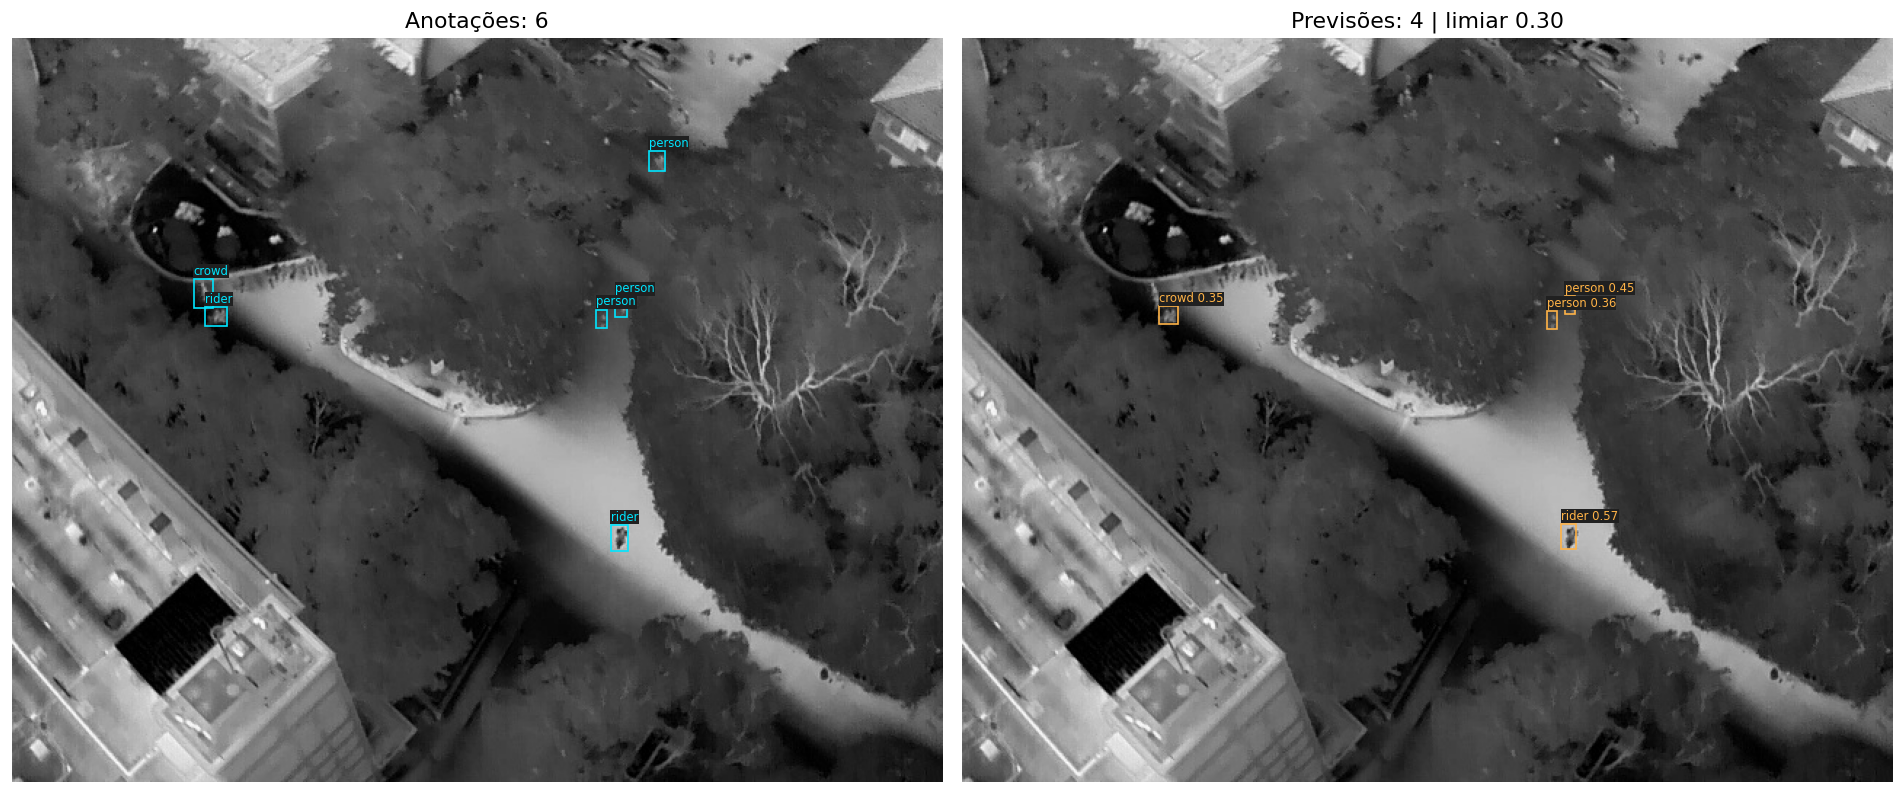

In [12]:
plt.figure(figsize=(16, 7))
plt.subplot(1, 2, 1)
mostrar_caixas(termica, anotacoes, f"Anotações: {len(anotacoes)}", "#00E5FF")
plt.subplot(1, 2, 2)
mostrar_caixas(termica, previsoes, f"Previsões: {len(previsoes)} | limiar {LIMIAR:.2f}", "#FFB347")
plt.tight_layout()
plt.show()

## Mudar o limiar sem executar a rede novamente

A rede já calculou `resultado`. Essa saída pode ser filtrada com diferentes limiares, sem repetir a inferência.
`caixas[:, 4]` seleciona a coluna de scores; a comparação cria valores booleanos, cuja soma conta as linhas aprovadas.

O modelo já aplica internamente um filtro mínimo de `0.05`, remove caixas redundantes por **NMS**
e retorna no máximo 100 detecções. O limiar de exibição apenas seleciona entre as previsões que chegaram até aqui;
reduzi-lo não recupera caixas descartadas internamente.

In [13]:
for limiar in (0.10, 0.30, 0.50):
    quantidade = sum(int((caixas[:, 4] >= limiar).sum()) for caixas in resultado)
    print(f"Limiar {limiar:.2f} | Previsões: {quantidade}")

Limiar 0.10 | Previsões: 36
Limiar 0.30 | Previsões: 4
Limiar 0.50 | Previsões: 1


Para ver o efeito na figura, altere `LIMIAR` na célula de seleção das previsões e execute novamente
daquela célula até a comparação. Não é necessário recarregar o modelo nem repetir sua chamada.
Aumentar o limiar exibe menos caixas, mas também pode esconder objetos reais.

## Exercício: uma cena noturna

Volte à célula **Escolher um par da validação** e substitua `"05350.jpg"` por `"04900.jpg"` em `ARQUIVO`.
Execute novamente dessa célula até o final. O modelo carregado será reutilizado; a preparação, a inferência
e a seleção das anotações serão refeitas para o novo par.

Compare o que uma pessoa consegue perceber no RGB e na térmica. Depois, identifique um objeto detectado
e procure uma possível falha. A comparação visual entre os sensores, sozinha, não mede quanto cada modalidade
contribuiu para a previsão; isso exigiria outro experimento.

## O que esta execução permite concluir

A execução carrega pesos treinados, fornece duas imagens e apresenta as detecções no referencial térmico.
As figuras ajudam a formular hipóteses sobre os erros. Para medir a qualidade do detector, é necessário
associar caixas previstas às anotações e calcular métricas em um conjunto definido.

Código e configuração: [repositório oficial do QFDet](https://github.com/NNNNerd/mmdet-rgbtdroneperson).
Dados e descrição: [RGBTDronePerson](https://nnnnerd.github.io/RGBTDronePerson/).
Artigo: Zhang et al., [Drone-based RGBT tiny person detection](https://doi.org/10.1016/j.isprsjprs.2023.08.016), 2023.